Target Variable Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:

df_a = pd.read_csv(
    "../data/processed/house_price_processed.csv"
)

print(df_a.shape)
df_a.head()

(14620, 34)


,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Sale_Year,Sale_Month,Sale_Quarter,Property_Age,Renovated,Basement_Percentage,schools_norm,airport_norm,grade_norm,Infrastructure_Score
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,2016,5,2,104,0,7.671233,0.5,0.733333,0.666667,0.620000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,2016,5,2,116,0,34.589041,0.5,0.966667,0.444444,0.623333
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,2016,5,2,86,0,0.000000,0.0,0.900000,0.444444,0.403333
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2016,5,2,24,0,0.000000,1.0,0.133333,0.555556,0.606667
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,2016,5,2,96,0,30.627306,0.0,0.966667,0.444444,0.423333


In [3]:
print(df_a.shape)

(14620, 34)


In [4]:
df_a["Price"].describe()

count    1.462000e+04
mean     5.389322e+05
std      3.675324e+05
min      7.800000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: Price, dtype: float64

In [5]:
df_a["Price"].skew()

4.269297720707116

In [6]:
print("Min Price:", df_a["Price"].min())
print("Max Price:", df_a["Price"].max())

Min Price: 78000
Max Price: 7700000


Visualization

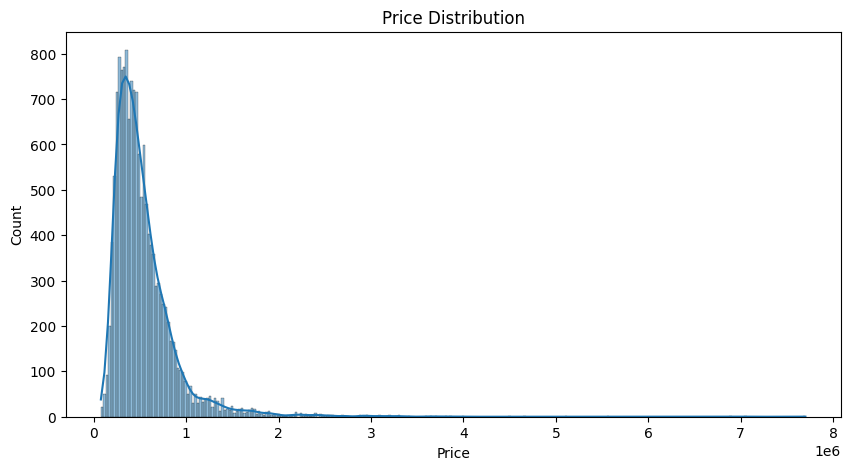

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df_a["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

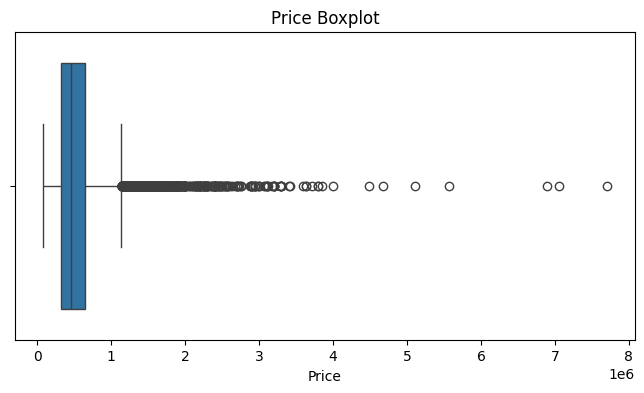

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_a["Price"])
plt.title("Price Boxplot")
plt.show()

Histogram

Strong right skew

Most houses are concentrated roughly between 200K–800K

Very few houses extend into multi-million prices

Long right tail

Boxplot

 Large number of high-price outliers

Many points beyond the upper whisker

Some houses priced up to 7.7 million

Outliers are real estate luxury properties, not necessarily bad data

Correlation Analysis

In [9]:
numeric_df = df_a.select_dtypes(include=["int64", "float64"])

corr_with_price = (
    numeric_df.corr()["Price"]
    .sort_values(ascending=False)
)

corr_with_price

Price                                    1.000000
living area                              0.712169
grade_norm                               0.671814
grade of the house                       0.671814
Area of the house(excluding basement)    0.615220
living_area_renov                        0.584924
number of bathrooms                      0.531735
number of views                          0.395973
Area of the basement                     0.330202
number of bedrooms                       0.308460
Lattitude                                0.297490
waterfront present                       0.263687
number of floors                         0.262732
Infrastructure_Score                     0.145216
Basement_Percentage                      0.134880
Renovation Year                          0.133173
Renovated                                0.132823
lot area                                 0.081992
lot_area_renov                           0.075535
Built Year                               0.050307


In [10]:
corr_with_price.head(15)

Price                                    1.000000
living area                              0.712169
grade_norm                               0.671814
grade of the house                       0.671814
Area of the house(excluding basement)    0.615220
living_area_renov                        0.584924
number of bathrooms                      0.531735
number of views                          0.395973
Area of the basement                     0.330202
number of bedrooms                       0.308460
Lattitude                                0.297490
waterfront present                       0.263687
number of floors                         0.262732
Infrastructure_Score                     0.145216
Basement_Percentage                      0.134880
Name: Price, dtype: float64

In [11]:
df_model = df_a.copy()

drop_cols = [
    "id",
    "Date",
    "Sale_Date",
    "Sale_Year",
    "Sale_Month",
    "Sale_Quarter",
    "grade_norm",
    "schools_norm",
    "airport_norm"
]

df_model = df_model.drop(columns=drop_cols)

print(df_model.shape)
print(df_model.columns.tolist())

(14620, 25)
['number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'waterfront present', 'number of views', 'condition of the house', 'grade of the house', 'Area of the house(excluding basement)', 'Area of the basement', 'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov', 'Number of schools nearby', 'Distance from the airport', 'Price', 'Property_Age', 'Renovated', 'Basement_Percentage', 'Infrastructure_Score']


In [12]:
drop_more = [
    "Built Year",
    "Renovation Year",
    "Area of the house(excluding basement)",
    "Area of the basement"
]

df_model = df_model.drop(columns=drop_more)

print(df_model.shape)
print(df_model.columns.tolist())

(14620, 21)
['number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'waterfront present', 'number of views', 'condition of the house', 'grade of the house', 'Postal Code', 'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov', 'Number of schools nearby', 'Distance from the airport', 'Price', 'Property_Age', 'Renovated', 'Basement_Percentage', 'Infrastructure_Score']


prepare X and y

In [13]:
X = df_model.drop(columns=["Price"])
y = df_model["Price"]

print(X.shape)
print(y.shape)
print(X.columns.tolist())

(14620, 20)
(14620,)
['number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'waterfront present', 'number of views', 'condition of the house', 'grade of the house', 'Postal Code', 'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov', 'Number of schools nearby', 'Distance from the airport', 'Property_Age', 'Renovated', 'Basement_Percentage', 'Infrastructure_Score']


ormal target and log target

In [14]:

y_log = np.log1p(y)

print(y.describe())
print(y_log.describe())

count    1.462000e+04
mean     5.389322e+05
std      3.675324e+05
min      7.800000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: Price, dtype: float64
count    14620.000000
mean        13.046129
std          0.525895
min         11.264477
25%         12.676079
50%         13.017005
75%         13.377007
max         15.856731
Name: Price, dtype: float64


Train/test split for original target and log target

In [15]:
from sklearn.model_selection import train_test_split

# Split for original target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Split for log target
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

print("Original target split:")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

print("\nLog target split:")
print(X_train_log.shape, X_test_log.shape, y_train_log.shape, y_test_log.shape)

Original target split:
(11696, 20) (2924, 20) (11696,) (2924,)

Log target split:
(11696, 20) (2924, 20) (11696,) (2924,)


Linear Regression on original Price

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression on original target
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression (Original Price)")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

Linear Regression (Original Price)
MAE : 124714.35944392646
RMSE: 197976.29212772258
R2  : 0.721864148486342


Linear Regression on log1p(Price)

In [17]:
# Linear Regression on log-transformed target
lr_log = LinearRegression()
lr_log.fit(X_train_log, y_train_log)

y_pred_log = lr_log.predict(X_test_log)

# Convert predictions back to original price scale
y_pred_lr_log_back = np.expm1(y_pred_log)
y_test_log_back = np.expm1(y_test_log)

lr_log_mae = mean_absolute_error(y_test_log_back, y_pred_lr_log_back)
lr_log_rmse = np.sqrt(mean_squared_error(y_test_log_back, y_pred_lr_log_back))
lr_log_r2 = r2_score(y_test_log_back, y_pred_lr_log_back)

print("Linear Regression (Log Target -> Back to Price Scale)")
print("MAE :", lr_log_mae)
print("RMSE:", lr_log_rmse)
print("R2  :", lr_log_r2)

Linear Regression (Log Target -> Back to Price Scale)
MAE : 106893.83400566809
RMSE: 196359.26283911552
R2  : 0.7263891051399649


LR comparison

Original target
MAE: 124,714
RMSE: 197,976
R²: 0.7219


Log target
MAE: 106,894
RMSE: 196,359
R²: 0.7264
Verdict

Use Linear Regression trained on log1p(Price) as the baseline LR model.

Random Forest Regressor

Original

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest (Original Price)")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest (Original Price)
MAE : 68158.58093194255
RMSE: 129923.2954928586
R2  : 0.880214387971873


Log

In [19]:
rf_log = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_log.fit(X_train_log, y_train_log)

y_pred_rf_log = rf_log.predict(X_test_log)

# Convert back to original price scale
y_pred_rf_log_back = np.expm1(y_pred_rf_log)
y_test_log_back = np.expm1(y_test_log)

rf_log_mae = mean_absolute_error(y_test_log_back, y_pred_rf_log_back)
rf_log_rmse = np.sqrt(mean_squared_error(y_test_log_back, y_pred_rf_log_back))
rf_log_r2 = r2_score(y_test_log_back, y_pred_rf_log_back)

print("Random Forest (Log Target -> Back to Price Scale)")
print("MAE :", rf_log_mae)
print("RMSE:", rf_log_rmse)
print("R2  :", rf_log_r2)

Random Forest (Log Target -> Back to Price Scale)
MAE : 68766.09295028835
RMSE: 135986.83136191563
R2  : 0.868772664993199


Random Forest comparison

Original target
MAE: 68,158.58
RMSE: 129,923.30
R²: 0.8802


Log target
MAE: 68,766.09
RMSE: 135,986.83
R²: 0.8688

Verdict

Use Random Forest trained on original Price as the official RF mode

XGBoost

original

In [20]:
from xgboost import XGBRegressor


In [21]:

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost (Original Price)")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2  :", xgb_r2)

XGBoost (Original Price)
MAE : 63562.11328125
RMSE: 116615.59141041133
R2  : 0.9034963250160217


LOg

In [22]:
xgb_log = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_log.fit(X_train_log, y_train_log)

y_pred_xgb_log = xgb_log.predict(X_test_log)

# Convert back to original price scale
y_pred_xgb_log_back = np.expm1(y_pred_xgb_log)
y_test_log_back = np.expm1(y_test_log)

xgb_log_mae = mean_absolute_error(y_test_log_back, y_pred_xgb_log_back)
xgb_log_rmse = np.sqrt(mean_squared_error(y_test_log_back, y_pred_xgb_log_back))
xgb_log_r2 = r2_score(y_test_log_back, y_pred_xgb_log_back)

print("XGBoost (Log Target -> Back to Price Scale)")
print("MAE :", xgb_log_mae)
print("RMSE:", xgb_log_rmse)
print("R2  :", xgb_log_r2)

XGBoost (Log Target -> Back to Price Scale)
MAE : 61453.94873514449
RMSE: 109080.92790271236
R2  : 0.9155638840326774


XGBoost comparison

Original target
MAE: 63,562.11
RMSE: 116,615.59
R²: 0.9035

Log target
MAE: 61,453.95
RMSE: 109,080.93
R²: 0.9156

Verdict

Use XGBoost trained on log1p(Price) as the official XGBoost result.

CatBoost

In [23]:
!pip install catboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from catboost import CatBoostRegressor

Original Price

In [25]:
from catboost import CatBoostRegressor


cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

cat_mae = mean_absolute_error(y_test, y_pred_cat)
cat_rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat))
cat_r2 = r2_score(y_test, y_pred_cat)

print("CatBoost (Original Price)")
print("MAE :", cat_mae)
print("RMSE:", cat_rmse)
print("R2  :", cat_r2)

CatBoost (Original Price)
MAE : 64388.471280681835
RMSE: 111249.56302464647
R2  : 0.9121731658933729


Log 

In [26]:
cat_log = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

cat_log.fit(X_train_log, y_train_log)

y_pred_cat_log = cat_log.predict(X_test_log)

# Convert back to original price scale
y_pred_cat_log_back = np.expm1(y_pred_cat_log)
y_test_log_back = np.expm1(y_test_log)

cat_log_mae = mean_absolute_error(y_test_log_back, y_pred_cat_log_back)
cat_log_rmse = np.sqrt(mean_squared_error(y_test_log_back, y_pred_cat_log_back))
cat_log_r2 = r2_score(y_test_log_back, y_pred_cat_log_back)

print("CatBoost (Log Target -> Back to Price Scale)")
print("MAE :", cat_log_mae)
print("RMSE:", cat_log_rmse)
print("R2  :", cat_log_r2)

CatBoost (Log Target -> Back to Price Scale)
MAE : 60713.901359031326
RMSE: 103548.35972129802
R2  : 0.9239118459525234


CatBoost trained on log1p(Price) as the official CatBoost result.

LightBGM

In [27]:
!pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from lightgbm import LGBMRegressor

LightGBM (Original Price)

In [29]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

lgbm_mae = mean_absolute_error(y_test, y_pred_lgbm)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
lgbm_r2 = r2_score(y_test, y_pred_lgbm)

print("LightGBM (Original Price)")
print("MAE :", lgbm_mae)
print("RMSE:", lgbm_rmse)
print("R2  :", lgbm_r2)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000501 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2320
[LightGBM] [Info] Number of data points in the train set: 11696, number of used features: 20
[LightGBM] [Info] Start training from score 537783.716399
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

Log

In [30]:
lgbm_log = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbose=-1
)

lgbm_log.fit(X_train_log, y_train_log)

y_pred_lgbm_log = lgbm_log.predict(X_test_log)

# Convert back to original price scale
y_pred_lgbm_log_back = np.expm1(y_pred_lgbm_log)
y_test_log_back = np.expm1(y_test_log)

lgbm_log_mae = mean_absolute_error(y_test_log_back, y_pred_lgbm_log_back)
lgbm_log_rmse = np.sqrt(mean_squared_error(y_test_log_back, y_pred_lgbm_log_back))
lgbm_log_r2 = r2_score(y_test_log_back, y_pred_lgbm_log_back)

print("LightGBM (Log Target -> Back to Price Scale)")
print("MAE :", lgbm_log_mae)
print("RMSE:", lgbm_log_rmse)
print("R2  :", lgbm_log_r2)

LightGBM (Log Target -> Back to Price Scale)
MAE : 61886.930938966514
RMSE: 105655.58538884073
R2  : 0.9207835234532944


LightGBM trained on log1p(Price) as the official LightGBM result.

Gradient Boosting

Original

In [31]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

gbr_mae = mean_absolute_error(y_test, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
gbr_r2 = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting (Original Price)")
print("MAE :", gbr_mae)
print("RMSE:", gbr_rmse)
print("R2  :", gbr_r2)

Gradient Boosting (Original Price)
MAE : 68149.6693566248
RMSE: 126273.50099801697
R2  : 0.8868498735132716


Log

In [32]:
gbr_log = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr_log.fit(X_train_log, y_train_log)

y_pred_gbr_log = gbr_log.predict(X_test_log)

# Convert back to original price scale
y_pred_gbr_log_back = np.expm1(y_pred_gbr_log)
y_test_log_back = np.expm1(y_test_log)

gbr_log_mae = mean_absolute_error(y_test_log_back, y_pred_gbr_log_back)
gbr_log_rmse = np.sqrt(mean_squared_error(y_test_log_back, y_pred_gbr_log_back))
gbr_log_r2 = r2_score(y_test_log_back, y_pred_gbr_log_back)

print("Gradient Boosting (Log Target -> Back to Price Scale)")
print("MAE :", gbr_log_mae)
print("RMSE:", gbr_log_rmse)
print("R2  :", gbr_log_r2)

Gradient Boosting (Log Target -> Back to Price Scale)
MAE : 64571.559048577794
RMSE: 110417.35528658734
R2  : 0.9134822369889029


Gradient Boosting trained on log1p(Price) as the official GBR result.

In [33]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "CatBoost",
        "LightGBM",
        "Gradient Boosting"
    ],
    "Best_Version": [
        "Log Target",
        "Original Target",
        "Log Target",
        "Log Target",
        "Log Target",
        "Log Target"
    ],
    "MAE": [
        106893.83400566809,
        68158.58093194255,
        61453.94873514449,
        60713.901359031326,
        61886.930938966514,
        64571.559048577794
    ],
    "RMSE": [
        196359.26283911552,
        129923.2954928586,
        109080.92790271236,
        103548.35972129802,
        105655.58538884073,
        110417.35528658734
    ],
    "R2": [
        0.7263891051399649,
        0.880214387971873,
        0.9155638840326774,
        0.9239118459525234,
        0.9207835234532944,
        0.9134822369889029
    ]
})

results_df = results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)
results_df

,Model,Best_Version,MAE,RMSE,R2
0,CatBoost,Log Target,60713.901359,103548.359721,0.923912
1,LightGBM,Log Target,61886.930939,105655.585389,0.920784
2,XGBoost,Log Target,61453.948735,109080.927903,0.915564
3,Gradient Boosting,Log Target,64571.559049,110417.355287,0.913482
4,Random Forest,Original Target,68158.580932,129923.295493,0.880214
5,Linear Regression,Log Target,106893.834006,196359.262839,0.726389


In [34]:
best_model_row = results_df.iloc[0]
print("Best Model Summary")
print(best_model_row)

Best Model Summary
Model                CatBoost
Best_Version       Log Target
MAE              60713.901359
RMSE            103548.359721
R2                   0.923912
Name: 0, dtype: object


Final selected model:

CatBoost Regressor trained on log-transformed target (log1p(Price))

In [35]:
print(X.columns.tolist())
print(X.shape)

['number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'waterfront present', 'number of views', 'condition of the house', 'grade of the house', 'Postal Code', 'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov', 'Number of schools nearby', 'Distance from the airport', 'Property_Age', 'Renovated', 'Basement_Percentage', 'Infrastructure_Score']
(14620, 20)


In [36]:
final_features = [
    'number of bedrooms',
    'number of bathrooms',
    'living area',
    'lot area',
    'number of floors',
    'waterfront present',
    'number of views',
    'condition of the house',
    'grade of the house',
    'Postal Code',
    'Lattitude',
    'Longitude',
    'living_area_renov',
    'lot_area_renov',
    'Number of schools nearby',
    'Distance from the airport',
    'Property_Age',
    'Renovated',
    'Basement_Percentage',
    'Infrastructure_Score'
]

print(X.columns.tolist() == final_features)

True


In [37]:


results = [
    ["Linear Regression", "Original", 124714.35944392646, 197976.29212772258, 0.721864148486342],
    ["Linear Regression", "Log",      106893.83400566809, 196359.26283911552, 0.7263891051399649],

    ["Random Forest",     "Original", 68158.58093194255, 129923.2954928586,  0.8802143879718738],
    ["Random Forest",     "Log",      68766.09295028834, 135986.83136191563, 0.8687726649931992],

    ["XGBoost",           "Original", 63562.11328125,    116615.59141041133, 0.9034963250160217],
    ["XGBoost",           "Log",      61453.94873514449, 109080.92790271236, 0.9155638840326774],

    ["CatBoost",          "Original", 64388.471280681835,111249.56302464647, 0.9121731658933729],
    ["CatBoost",          "Log",      60713.901359031326,103548.35972129802, 0.9239118459525234],

    ["LightGBM",          "Original", 67601.52941701972, 125280.59031892185, 0.8886223160630671],
    ["LightGBM",          "Log",      61886.930938966514,105655.58538884073, 0.9207835234532944],

    ["Gradient Boosting", "Original", 68149.6693566248,  126273.50099801697, 0.8868498735132716],
    ["Gradient Boosting", "Log",      64571.559048577794,110417.35528658734, 0.9134822369889029],
]

results_df = pd.DataFrame(results, columns=["Model", "Target", "MAE", "RMSE", "R2"])

# sort by best R2, then lowest RMSE
results_df = results_df.sort_values(by=["R2", "RMSE"], ascending=[False, True]).reset_index(drop=True)

print(results_df)

                Model    Target            MAE           RMSE        R2
0            CatBoost       Log   60713.901359  103548.359721  0.923912
1            LightGBM       Log   61886.930939  105655.585389  0.920784
2             XGBoost       Log   61453.948735  109080.927903  0.915564
3   Gradient Boosting       Log   64571.559049  110417.355287  0.913482
4            CatBoost  Original   64388.471281  111249.563025  0.912173
5             XGBoost  Original   63562.113281  116615.591410  0.903496
6            LightGBM  Original   67601.529417  125280.590319  0.888622
7   Gradient Boosting  Original   68149.669357  126273.500998  0.886850
8       Random Forest  Original   68158.580932  129923.295493  0.880214
9       Random Forest       Log   68766.092950  135986.831362  0.868773
10  Linear Regression       Log  106893.834006  196359.262839  0.726389
11  Linear Regression  Original  124714.359444  197976.292128  0.721864


#catboost Feature Importance

                      Feature  Importance
10                  Lattitude   44.775658
2                 living area   17.819410
8          grade of the house   11.758027
11                  Longitude    6.233802
12          living_area_renov    3.908485
9                 Postal Code    2.772077
6             number of views    2.493685
16               Property_Age    2.245976
3                    lot area    1.625616
7      condition of the house    1.491743
13             lot_area_renov    1.292534
5          waterfront present    1.107864
1         number of bathrooms    1.053663
18        Basement_Percentage    0.476850
17                  Renovated    0.344494
0          number of bedrooms    0.235786
4            number of floors    0.169852
19       Infrastructure_Score    0.126969
15  Distance from the airport    0.059068
14   Number of schools nearby    0.008440


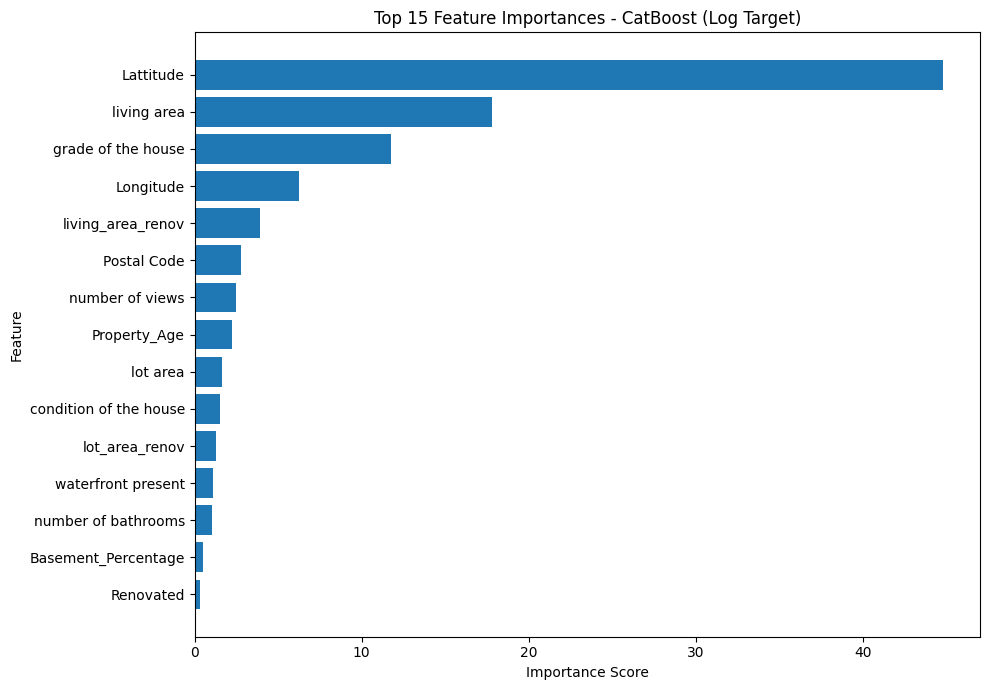

In [38]:

# CatBoost Feature Importance
cat_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_log.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(cat_feature_importance)

# Plot top 15 features
top_n = 15
top_features = cat_feature_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Feature Importances - CatBoost (Log Target)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../reports/figures/catboost_feature_importance_top15.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    cat_log,
    "../models/catboost_log_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [41]:
X_test_log.to_csv(
    "../models/X_test_log.csv",
    index=False
)

y_test_log.to_csv(
    "../models/y_test_log.csv",
    index=False
)

print("Test data saved")

Test data saved


# Actual vs Predicted Plot

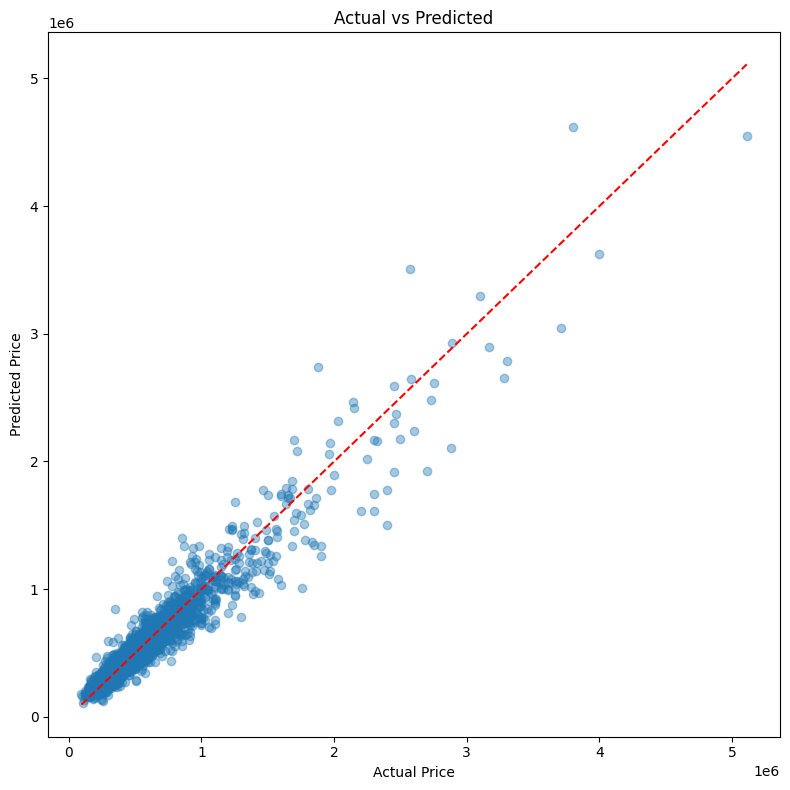

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    y_test_log_back,
    y_pred_cat_log_back,
    alpha=0.4
)

plt.plot(
    [y_test_log_back.min(), y_test_log_back.max()],
    [y_test_log_back.min(), y_test_log_back.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.tight_layout()

plt.savefig(
    "../reports/figures/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Residual plot

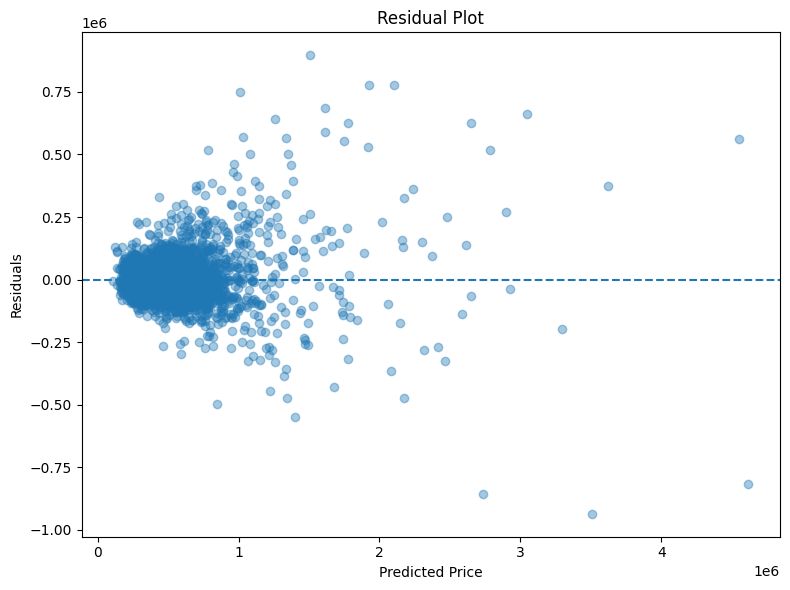

In [43]:
residuals = y_test_log_back - y_pred_cat_log_back

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_cat_log_back,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()

plt.savefig(
    "../reports/figures/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Residual distribution

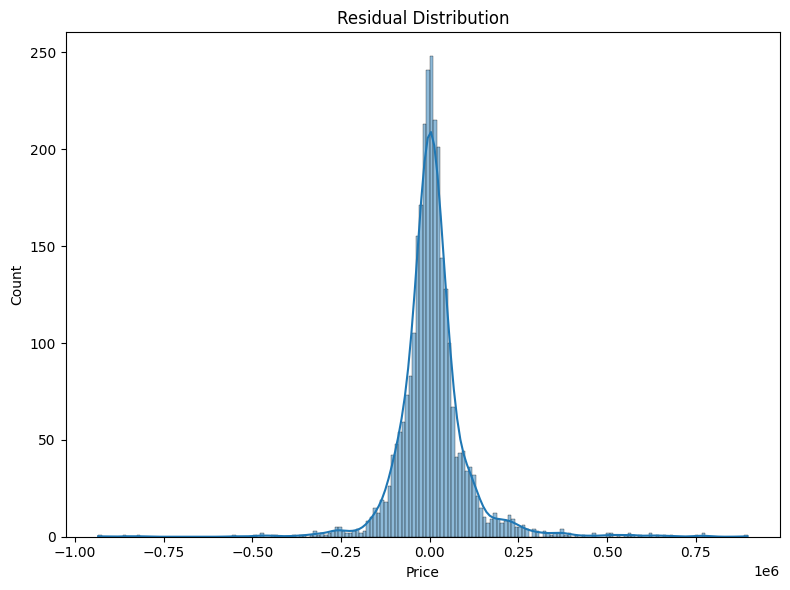

In [44]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/figures/residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()